<a href="https://colab.research.google.com/github/Ruturaj2472/RAG-LangGraph-Qdrant-Reranking/blob/main/LangGraph_Qdrant_Hybrid_Rerank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup & Environment

Install all required packages:
- `langgraph`, `langchain`, `langchain-openai` - orchestration + OpenAI generation
- `qdrant-client`, `langchain-qdrant` - vector DB
- `fastembed` - open-source dense + sparse embedding models (runs locally, CPU-friendly)
- `sentence-transformers` - open-source cross-encoder reranker

In [1]:
!pip install -q langgraph langchain langchain-openai langchain-core \
    qdrant-client langchain-qdrant \
    fastembed sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.7/571.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.2/396.2 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.1/324.1 kB 8.0 MB/s eta 0:00:00


In [2]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

# Sanity check (does not print the key itself)
assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY not found - add it via the Colab Secrets (key icon) panel."
print("OpenAI API key loaded from Colab secrets ✔")

OpenAI API key loaded from Colab secrets ✔


In [3]:
from typing import TypedDict, List, Optional

import numpy as np

# Qdrant client for interacting with the vector database.
# - QdrantClient: Connects to the Qdrant server.
# - qmodels: Contains helper models for collections, search parameters, etc.
from qdrant_client import QdrantClient, models as qmodels

# FastEmbed provides lightweight embedding models.
from fastembed import TextEmbedding, SparseTextEmbedding

# CrossEncoder is used for reranking retrieved documents by
# computing relevance scores between the query and documents.
from sentence_transformers import CrossEncoder
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END


## 2. Embedding & Sparse Vector Setup


In [4]:
# Initialize the dense embedding model.
dense_model = TextEmbedding(model_name="BAAI/bge-small-en-v1.5")
DENSE_DIM = 384

# Initialize the sparse embedding model.
sparse_model= SparseTextEmbedding(model_name="Qdrant/bm25")

print("Dense model loaded:", dense_model.model_name)
print("Sparse model loaded:", sparse_model.model_name)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Dense model loaded: BAAI/bge-small-en-v1.5
Sparse model loaded: Qdrant/bm25


In [5]:
def embed_dense(texts: List[str]) -> List[List[float]]:
    """
    Generate dense vectore embeddings for a list of text documents.

    Parameters:
        texts (List[str]):
            A list of input strings to be converted into dense embeddings.

    Returns:
        List[List[float]]:
            A list of dense vectors, where each vector is represented
            as a Python list of floating-point values.

    Note:
        FastEmbed returns Numpy arrays, which are converted to Python
        lists for easier serialization and compatibility with Qdrant.
    """
    return [vec.tolist() for vec in dense_model.embed(texts)]

def embed_sparse(texts: List[str]):
    """
    Generate sparse embeddings for a list of text documents.

    Parameters:
        texts (List[str]):
            A list of input strings.

    Returns:
        List:
            A list of sparse embedding objects containing:
            - indices : Positions of non-zero terms
            - values  : Importance score for each term

    Note:
        Sparse embeddings are primarily used for keyword-based retrieval
        and are often combined with dense embeddings to perform
        Hybrid Search.
    """
    return list(sparse_model.embed(texts))

    #SMOKE TEST
    sample=[
        "LangGraph makes it easy to build stateful, cyclic LLM applications."
    ]

    d= embed_dense(sample)
    s= embed_sparse(sample)
    print("Dense vector length:", len(d[0]))
    print("Sparse non-zero terms:", len(s[0].indices))



## 3. Qdrant Collection Setup



In [6]:
# Name of the collection that will store our documents.
COLLECTION_NAME = "langgraph_hybrid_demo"

# Create an in-memory Qdrant instance.
client = QdrantClient(":memory:")

# Create a new collection capable of storing both
# dense and sparse embeddings for Hybrid Search.
client.create_collection(
    collection_name=COLLECTION_NAME,

    # Configuration for dense vector embeddings.
    vectors_config={
        "dense": qmodels.VectorParams(
            size=DENSE_DIM,                     # Dimension of dense vectors (384)
            distance=qmodels.Distance.COSINE    # Similarity metric for vector search
        ),
    },

    # Configuration for sparse vectors.
    sparse_vectors_config={
        "sparse": qmodels.SparseVectorParams(),
    },
)

# Confirm successful collection creation.
print(
    f"Collection '{COLLECTION_NAME}' created with dense + sparse named vectors."
)


Collection 'langgraph_hybrid_demo' created with dense + sparse named vectors.


### Sample Corpus

A small, self-contained set of ~18 short documents about AI/ML/agent topics - enough to see meaningful differences between dense, sparse, and hybrid search without needing external files.

In [7]:
documents = [
    {"id": 0, "text": "LangGraph is a library for building stateful, multi-actor applications with LLMs, built on top of LangChain.", "topic": "langgraph"},
    {"id": 1, "text": "A StateGraph in LangGraph defines nodes, edges, and a shared state object that flows through the graph.", "topic": "langgraph"},
    {"id": 2, "text": "Unlike LCEL chains, which are directed acyclic graphs, LangGraph supports cycles and conditional branching.", "topic": "langgraph"},
    {"id": 3, "text": "Qdrant is an open-source vector database written in Rust, optimized for high-performance similarity search.", "topic": "qdrant"},
    {"id": 4, "text": "Qdrant supports named vectors, allowing multiple embeddings (e.g., dense and sparse) to be stored per point.", "topic": "qdrant"},
    {"id": 5, "text": "Hybrid search combines dense semantic vectors with sparse lexical vectors to improve retrieval accuracy.", "topic": "hybrid_search"},
    {"id": 6, "text": "Reciprocal Rank Fusion (RRF) is a common method for merging ranked lists from multiple retrieval systems.", "topic": "hybrid_search"},
    {"id": 7, "text": "BM25 is a classic sparse retrieval algorithm based on term frequency and inverse document frequency.", "topic": "hybrid_search"},
    {"id": 8, "text": "Dense embeddings encode semantic meaning, allowing retrieval of conceptually similar text even without shared keywords.", "topic": "embeddings"},
    {"id": 9, "text": "Cross-encoder rerankers score a query-document pair jointly, producing more accurate relevance scores than bi-encoders.", "topic": "reranking"},
    {"id": 10, "text": "BAAI/bge-reranker-base is an open-source cross-encoder model commonly used for reranking retrieved passages.", "topic": "reranking"},
    {"id": 11, "text": "Reranking is typically applied to a small candidate set (e.g., top 20-50) after initial retrieval, since cross-encoders are more compute-intensive.", "topic": "reranking"},
    {"id": 12, "text": "Agentic RAG systems combine retrieval-augmented generation with agent-style decision making, such as deciding whether to retrieve at all.", "topic": "agents"},
    {"id": 13, "text": "LangGraph's checkpointing feature allows persisting graph state, enabling resumability and human-in-the-loop workflows.", "topic": "langgraph"},
    {"id": 14, "text": "Conditional edges in LangGraph route execution to different nodes based on the current state, enabling dynamic control flow.", "topic": "langgraph"},
    {"id": 15, "text": "Open-source embedding models like bge-small-en-v1.5 can run efficiently on CPU, making them practical for local development.", "topic": "embeddings"},
    {"id": 16, "text": "Vector databases like Qdrant, Weaviate, and Milvus are optimized for approximate nearest neighbor search at scale.", "topic": "qdrant"},
    {"id": 17, "text": "SPLADE is a sparse retrieval model that learns term expansions, unlike BM25 which relies purely on exact term matches.", "topic": "hybrid_search"},
]

print(f"Corpus size: {len(documents)} documents")

Corpus size: 18 documents


## 4. Ingestion Pipeline
Steps:
1. Generate dense embeddings for all documents
2. Generate sparse embeddings for all documents
3. Upsert into Qdrant as points with both named vectors + payload metadata

In [8]:
# Extract the text content from each document.
# These texts will be converted into embeddings for storage.
texts = [d["text"] for d in documents]

# Generate dense and sparse embeddings.
dense_vectors = embed_dense(texts)
sparse_vectors = embed_sparse(texts)

# Prepare a list of Qdrant Point objects.
points = []

for doc, dense_vec, sparse_vec in zip(documents, dense_vectors, sparse_vectors):
    points.append(
        qmodels.PointStruct(
            id=doc["id"],

            # Store multiple named vectors for Hybrid Search.
            vector = {
                "dense": dense_vec,

                "sparse": qmodels.SparseVector(
                    indices=sparse_vec.indices.tolist(),
                    values=sparse_vec.values.tolist()
                ),
            },

            # Store additional metadata that can be retrieved
            # along with the search results.
            payload={
                "text": doc["text"],
                "topic":doc["topic"],
            },
        )
    )

# Insert (or update) all points into the Qdrant collection.
# - Insert if the point ID does not exist.
# - Update if the point ID already exists.
client.upsert(
    collection_name = COLLECTION_NAME,
    points = points,
)

# Display the number of documents successfully stored.
print(f"Upserted {len(points)} points into '{COLLECTION_NAME}'.")


Upserted 18 points into 'langgraph_hybrid_demo'.



## 5. Hybrid Search in Qdrant

We'll compare three retrieval modes for the same query:

1. **Dense-only** - pure semantic vector search
2. **Sparse-only** - pure lexical/BM25-style search
3. **Hybrid** - dense + sparse combined via Qdrant's **Query API** using **RRF (Reciprocal Rank Fusion)**

Qdrant's `query_points` supports a `prefetch` list (candidate generation from each vector type) plus a top-level fusion query that merges the ranked lists.

In [17]:
def dense_search(query: str, top_k: int=5):

     # Convert the query into a dense embedding.
     q_vec = embed_dense([query])[0]

     # Search the dense vector index.
     results = client.query_points(
         collection_name=COLLECTION_NAME,
         query=q_vec,
         using="dense",
         limit=top_k,

        )
     return results.points

def sparse_search(query: str, top_k: int =5):\

    # Generate sparse embedding for the query.
    q_sparse = embed_sparse([query])[0]

    # Search the sparse vector index.
    results = client.query_points(
        collection_name = COLLECTION_NAME,
        query=qmodels.SparseVector(
            indices=q_sparse.indices.tolist(),
            values=q_sparse.values.tolist(),
        ),
        using="sparse",
        limit=top_k,
    )
    return results.points

def hybrid_search(query: str, top_k: int = 5, prefetch_k: int =20):

    # Generate dense and sparse embeddings for the query.
    q_vec = embed_dense([query])[0]
    q_sparse = embed_sparse([query])[0]

    # Execute Hybrid Search.
    results = client.query_points(
        collection_name=COLLECTION_NAME,

        # Retrieve candidates independently from both indexes.
        prefetch = [
            qmodels.Prefetch(
                query=q_vec,
                using="dense",
                limit=prefetch_k,
            ),

            qmodels.Prefetch(
                query=qmodels.SparseVector(
                    indices=q_sparse.indices.tolist(),
                    values=q_sparse.values.tolist(),
                ),
                using="sparse",
                limit=prefetch_k,
            ),
        ],

        # Merge both rankings using Reciprocal Rank Fusion (RRF).
        query=qmodels.FusionQuery(
            fusion=qmodels.Fusion.RRF

        ),

        # Return the final top-k documents.
        limit=top_k,

    )

    return results.points

In [18]:
def show_results(title: str, points):
    print(f"\n--- n{title} ---")

    for p in points:
        # Round the score for better readability.
        score = round(p.score,4) if p.score is not None else None

        # Display the retrieval score and document text.
        print(f"[{score}] {p.payload['text']}")

# =============================================================================
# COMPARE DENSE, SPARSE, AND HYBRID SEARCH
# =============================================================================

query = "How does LangGraph differ from a normal LangChain chain?"

# Execute Dense Search.
show_results("Dense-only", dense_search(query))

# Execute Sparse Search.
show_results("Similarity-only", sparse_search(query))

# Execute Hybrid Search.
show_results(
    "Hybrid (RRF fusion)",
    hybrid_search(query)
)


--- nDense-only ---
[0.8139] LangGraph is a library for building stateful, multi-actor applications with LLMs, built on top of LangChain.
[0.809] Unlike LCEL chains, which are directed acyclic graphs, LangGraph supports cycles and conditional branching.
[0.761] A StateGraph in LangGraph defines nodes, edges, and a shared state object that flows through the graph.
[0.7425] Conditional edges in LangGraph route execution to different nodes based on the current state, enabling dynamic control flow.
[0.6689] LangGraph's checkpointing feature allows persisting graph state, enabling resumability and human-in-the-loop workflows.

--- nSimilarity-only ---
[5.4881] LangGraph is a library for building stateful, multi-actor applications with LLMs, built on top of LangChain.
[5.4881] Unlike LCEL chains, which are directed acyclic graphs, LangGraph supports cycles and conditional branching.
[5.4452] Conditional edges in LangGraph route execution to different nodes based on the current state, enabli

## 6. Open-Source Reranking

In [19]:
# Initialize a CrossEncoder model for reranking retrieved documents.
#
# Unlike embedding models, a CrossEncoder jointly processes the
# query and document to produce a highly accurate relevance score.
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(
        query: str,
        candidates: List[qmodels.ScoredPoint],
        top_n: int = 3,
):

    """
    Rerank retrieved documents using a CrossEncoder.

    Workflow:
        1. Create (query, document) pairs.
        2. Predict a relevance score for each pair.
        3. Sort documents by the predicted score.
        4. Return the top-ranked documents.

    Parameters:
        query (str):
            User's search query.

        candidates (List[ScoredPoint]):
            Documents retrieved from Dense, Sparse, or Hybrid Search.

        top_n (int):
            Number of highest-ranked documents to return.

    Returns:
        List[Tuple[ScoredPoint, float]]:
            A list containing:
            - The retrieved document
            - Its CrossEncoder relevance score
    """

    # Create (query, document) pairs required by the CrossEncoder.
    pairs = [
        (query, c.payload["text"])
        for c in candidates
    ]

    # Predict relevance scores for each pair.
    scores = reranker.predict(pairs)

    # Sort candidate documents by their predicted relevance score
    # in descending order.
    reranked = sorted(
        zip(candidates, scores),
        key=lambda pair: pair[1],
        reverse=True,
    )

    # Return only the top-N highest ranked documents.
    return[
        (candidate,float(score))
        for candidate,score in reranked[:top_n]
    ]


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [20]:
# Retrieve the top candidate documents using Hybrid Search.
candidates = hybrid_search(
    query,
    top_k=10,
)

# Display the retrieved documents before reranking.
# These documents are ordered according to Reciprocal Rank Fusion (RRF).
show_results(
    "Hybrid search candidates (pre-rerank)",
    candidates,
)

# Apply CrossEncoder reranking.
reranked = rerank(
    query,
    candidates,
    top_n=3,
)

# DISPLAY FINAL RERANKED RESULTS
print("\n--- After reranking (top 3) ---")

for point, score in reranked:
    print(
        f"[{round(score,4)}] {point.payload['text']}"
    )



--- nHybrid search candidates (pre-rerank) ---
[1.0] LangGraph is a library for building stateful, multi-actor applications with LLMs, built on top of LangChain.
[0.6667] Unlike LCEL chains, which are directed acyclic graphs, LangGraph supports cycles and conditional branching.
[0.45] A StateGraph in LangGraph defines nodes, edges, and a shared state object that flows through the graph.
[0.45] Conditional edges in LangGraph route execution to different nodes based on the current state, enabling dynamic control flow.
[0.3333] LangGraph's checkpointing feature allows persisting graph state, enabling resumability and human-in-the-loop workflows.
[0.1429] Qdrant is an open-source vector database written in Rust, optimized for high-performance similarity search.
[0.125] BAAI/bge-reranker-base is an open-source cross-encoder model commonly used for reranking retrieved passages.
[0.1111] Qdrant supports named vectors, allowing multiple embeddings (e.g., dense and sparse) to be stored per poi

## 7. LangGraph Agent Construction

Now we wire retrieval → rerank → generate into a LangGraph `StateGraph`.

### 7.1 Define State

Our state carries everything downstream nodes might need: the original query, retrieved docs, reranked docs, and the final answer.

In [21]:
class RAGState(TypedDict):
    query: str
    retrieved_docs: List[dict]
    reranked_docs: List[dict]
    answer: str

### 7.2 Define Nodes


In [23]:
# LANGGRAPH NODE 1: RETRIEVE DOCUMENTS

def retrieve_node(state: RAGState) -> dict:

    # Retrieve candidate documents using Hybrid Search.
    results = hybrid_search(
        state["query"],
        top_k=10,
    )

    # Extract only the information needed for downstream nodes.
    docs = [
        {
        "text": r.payload["text"],
        "topic": r.payload["topic"],
        "score": r.score,
        }
        for r in results
    ]

    return {
        "retrieved_docs": docs,
    }

# LANGGRAPH NODE 2: RERANK DOCUMENTS

def rerank_node(state: RAGState) -> dict:

    # Create query-document pairs.
    pairs = [
        (state["query"], d["text"])
        for d in state["retrieved_docs"]
    ]

    # Predict semantic relevance scores.
    scores = reranker.predict(pairs)

    # Sort documents by descending relevance.
    combined = sorted(
        zip(state["retrieved_docs"], scores),
        key=lambda x: x[1],
        reverse=True,
    )

    # Keep only the top 3 documents.
    top_docs = [
        {
            **doc,
            "rerank_score": float(score),
        }
        for doc,score in combined[:3]
    ]

    return {
        "reranked_docs": top_docs
    }

# INITIALIZE THE LANGUAGE MODEL

# Create the LLM used for answer generation.

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

# LANGRAPH NODE 3: GENERATE ANSWER

def generate_node(state: RAGState) -> dict:

    # Combine retrieved documents into a single context block.
    context = "\n".join(
        f"- {doc['text']}"
        for doc in state["reranked_docs"]
    )

    # Construct the prompt.
    prompt = (
        "Answer the question using only the context below. "
        "If the context is insufficient, say so.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {state['query']}\n\n"
        "Answer:"
    )

    # Generate the answer.
    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

### 7.3 Build & Compile the Graph

The pipeline here is linear (`retrieve → rerank → generate`), but expressing it in LangGraph means it's trivial to later add a conditional edge - e.g., skip `rerank_node` if `len(retrieved_docs) < 3`, or loop back to `retrieve_node` with a rewritten query if `generate_node` decides context was insufficient.


In [25]:
# BUILD THE LANGGRAPH WORKFLOW

# Create a new LangGraph workflow using the RAGState schema.
graph_builder = StateGraph(RAGState)

# Register workflow nodes
# Node 1:
graph_builder.add_node("retrieve", retrieve_node,)

# Node 2:
graph_builder.add_node("rerank", rerank_node)

#Node 3:
graph_builder.add_node("generate", generate_node)

# Define execution flow
# Start the workflow by executing the retrieval node.
graph_builder.add_edge(START, "retrieve")

# After retrieval, rerank the retrieved documents.
graph_builder.add_edge("retrieve", "rerank")

# Pass the reranked documents to the answer generation node.
graph_builder.add_edge("rerank", "generate")

# End the workflow after the answer has been generated.
graph_builder.add_edge("generate", END)

# Compile the graph

# Compile the workflow into an executable LangGraph application.
graph = graph_builder.compile()

# Confirm successful compilation.
print("Graph compiled ✔")


Graph compiled ✔


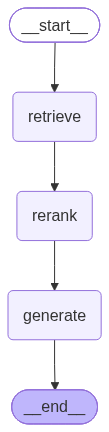

In [26]:
# Visualize the graph structure (Mermaid, rendered inline in Colab)
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 8. Running the Graph

We invoke the compiled graph with an initial state containing just the `query` - the rest of the fields get filled in as execution proceeds through each node.

In [27]:
# The input to the graph is the initial workflow state,
# which contains only the user's query.
result = graph.invoke(
    {
    "query": "What is the difference between LangGraph and a LangChain LCEL chain?"
    }
)

# Display the original user query.
print("QUERY:", result["query"])

# Display the final answer generated by the LLM
print("\nFINAL ANSWER:\n")
print(result["answer"])


QUERY: What is the difference between LangGraph and a LangChain LCEL chain?

FINAL ANSWER:

The difference between LangGraph and a LangChain LCEL chain is that LangGraph supports cycles and conditional branching, while LCEL chains are directed acyclic graphs. Additionally, LangGraph is designed for building stateful, multi-actor applications with LLMs and includes a StateGraph that defines nodes, edges, and a shared state object.


### Streaming Intermediate State

To make the retrieve → rerank → generate pipeline transparent (useful for debugging), we can use `.stream()` instead of `.invoke()` to see the state update after each node runs.

In [28]:
# Execute the graph in streaming mode.
# Each iteration returns the state updates produced by a single node.

for step in graph.stream(
    {
        "query": "How does hybrid search combine dense and sparse retrieval?"
    }
):

    # Each streamed update contains a single node name
    # and the state changes produced by that node.
    node_name = list(step.keys())[0]
    node_output = step[node_name]

    print(f"\n=== After node: {node_name} ===")

    # Display the outputs generated by the current node.
    for key, value in node_output.items():

        # Retrieval node output.
        if key == "retrieved_docs":
            print(f"  retrieved_docs: {len(value)} docs")

        # Reranking node output.
        elif key == "reranked_docs":
            print(
                " reranked_docs:",
                [
                    doc["text"][:60] + "..."
                    for doc in value
                ],
            )

        # Generation node output (or any future node outputs).
        else:
            print(f"  {key}: {value}")



=== After node: retrieve ===
  retrieved_docs: 10 docs

=== After node: rerank ===
 reranked_docs: ['Hybrid search combines dense semantic vectors with sparse le...', 'BM25 is a classic sparse retrieval algorithm based on term f...', 'SPLADE is a sparse retrieval model that learns term expansio...']

=== After node: generate ===
  answer: Hybrid search combines dense semantic vectors, which capture the meaning of the content, with sparse lexical vectors, which focus on the exact terms used in the documents. This combination aims to improve retrieval accuracy by leveraging the strengths of both approaches.


In [29]:
# Try a few more queries end-to-end
test_queries = [
    "What open-source model can be used for reranking retrieved documents?",
    "Why would I use RRF fusion instead of dense search alone?",
    "What is Qdrant and what makes it different from a regular database?",
]

for q in test_queries:
    out = graph.invoke({"query": q})
    print(f"\nQ: {q}\nA: {out['answer']}\n{'-'*80}")


Q: What open-source model can be used for reranking retrieved documents?
A: BAAI/bge-reranker-base is an open-source model that can be used for reranking retrieved documents.
--------------------------------------------------------------------------------

Q: Why would I use RRF fusion instead of dense search alone?
A: You would use RRF fusion instead of dense search alone to combine ranked lists from multiple retrieval systems, potentially improving retrieval accuracy by leveraging the strengths of different methods. RRF can enhance the results by integrating diverse perspectives from various retrieval systems, which may capture different aspects of the data that dense search alone might miss.
--------------------------------------------------------------------------------

Q: What is Qdrant and what makes it different from a regular database?
A: Qdrant is an open-source vector database written in Rust, optimized for high-performance similarity search. It differs from a regular datab